In [19]:
path = '/home/miguel/GI/0 - Data Exploration & Analysis/GI-Roberta/gi-roberta-dataset/4D_MRI_GI_Roberta/4D_MRI_GI_Roberta/Different ways to view the data/View-3D-at-time-X'

In [20]:
import os
import torch
import cv2
from scipy.io import loadmat

In [21]:
import matplotlib.pyplot as plt

In [22]:
image_folder_path = 'all-cine-mri-pngs-corrected'
os.makedirs(image_folder_path, exist_ok=True)

In [23]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

def display_slices(image_mat, mask_mat, num=10):
    """
    Display up to 'num' slices from image_mat, clearing output after each.
    """
    for i in range(min(num, image_mat.shape[2])):
        padX = 1
        padY = 8
        image = image_mat[:, :, i][padX:-padX, padY:-padY]  # Crop the image to remove borders
        mask = mask_mat[:, :, i][padX:-padX, padY:-padY]  # Crop the mask to remove borders


        # image = image_mat[:, :, i]#[padX:-padX, padY:-padY]  # Crop the image to remove borders
        # mask = mask_mat[:, :, i]#[padX:-padX, padY:-padY]  # Crop the mask to remove borders

        image_uint8 = (image * 255).astype('uint8')
        mask_uint8 = (mask).astype('uint8')

        mask_uint8[mask_uint8 > 0] = 255  # Replace all mask values greater than 0 with 255

        # Resize to 256x256
        image_uint8 = cv2.resize(image_uint8, (256, 256), interpolation=cv2.INTER_LINEAR)
        mask_uint8 = cv2.resize(mask_uint8, (256, 256), interpolation=cv2.INTER_LINEAR)

        # Replace all mask values greater than 0 with 255

        fig, ax = plt.subplots()
        ax.imshow(255 - image_uint8, cmap='gray')

        # Plot the mask
        ax.imshow(mask_uint8, cmap='jet', alpha=0.5)
        plt.show()

        # Clear the cell output and close the figure
        clear_output(wait=True)
        plt.close(fig)

# Example usage:
# display_slices(image_mat, mask_mat, num=10)


In [14]:
file = 'FD_027_time_1_slice_1_image.png'

In [15]:
os.listdir(path)

['FD_029_mask_time_107.mat',
 'FD_027_mask_time_71.mat',
 'FD_031_image_time_47.mat',
 'FD_027_image_time_102.mat',
 'FD_031_image_time_57.mat',
 'FD_031_image_time_14.mat',
 'FD_032_mask_time_46.mat',
 'FD_027_image_time_96.mat',
 'FD_027_mask_time_58.mat',
 'FD_032_mask_time_110.mat',
 'FD_030_image_time_88.mat',
 'FD_030_image_time_125.mat',
 'FD_032_mask_time_120.mat',
 'FD_030_image_time_19.mat',
 'FD_031_mask_time_119.mat',
 'FD_032_image_time_57.mat',
 'FD_027_mask_time_120.mat',
 'FD_032_image_time_49.mat',
 'FD_030_image_time_121.mat',
 'FD_030_image_time_104.mat',
 'FD_029_image_time_69.mat',
 'FD_029_mask_time_86.mat',
 'FD_029_mask_time_69.mat',
 'FD_030_image_time_41.mat',
 'FD_032_mask_time_36.mat',
 'FD_031_mask_time_13.mat',
 'FD_029_image_time_110.mat',
 'FD_031_mask_time_87.mat',
 'FD_032_mask_time_121.mat',
 'FD_027_mask_time_69.mat',
 'FD_027_mask_time_130.mat',
 'FD_031_image_time_102.mat',
 'FD_030_image_time_2.mat',
 'FD_027_image_time_101.mat',
 'FD_027_image_ti

In [16]:
from tqdm import tqdm

In [17]:
padX = 1
padY = 8
for file in tqdm(os.listdir(path)):
    if file.endswith('.mat'):
        if 'image' in file:
            # Load the .mat file
            file_path = os.path.join(path, file)
            image_mat = loadmat(file_path)['image_time']

            for i in range(image_mat.shape[2]):
                image = image_mat[:, :, i][padX:-padX, padY:-padY]  # Crop the image to remove borders

                # image = image_mat[:, :, i]#[padX:-padX, padY:-padY]  # Crop the image to remove borders
                # mask = mask_mat[:, :, i]#[padX:-padX, padY:-padY]  # Crop the mask to remove borders

                image_uint8 = (image * 255).astype('uint8')

                # Resize to 256x256
                image_uint8 = 255 - cv2.resize(image_uint8, (256, 256), interpolation=cv2.INTER_LINEAR)

                file_split = file.split('_')

                # Save the image
                file_name = f"FD_{file_split[1]}_time_{file.split('_')[4][:-4]}_slice_{i}_image"

                cv2.imwrite(os.path.join(image_folder_path, f"{file_name}.png"), image_uint8)
                # print(f"Saved {file_name}.png")
            

        elif 'mask' in file:
            # Load the .mat file
            file_path = os.path.join(path, file)
            mask_mat = loadmat(file_path)['mask_time']

            for i in range(mask_mat.shape[2]):
                mask = mask_mat[:, :, i][padX:-padX, padY:-padY]  # Crop the mask to remove borders
                mask_uint8 = (mask).astype('uint8')
                mask_uint8[mask_uint8 > 0] = 255  # Replace all mask values greater than 0 with 255
                mask_uint8 = cv2.resize(mask_uint8, (256, 256), interpolation=cv2.INTER_LINEAR)

                file_split = file.split('_')
                # Save the mask
                file_name = f"FD_{file_split[1]}_time_{file.split('_')[4][:-4]}_slice_{i}_mask"
                cv2.imwrite(os.path.join(image_folder_path, f"{file_name}.png"), mask_uint8)

  7%|▋         | 96/1321 [00:04<00:54, 22.32it/s]


KeyboardInterrupt: 

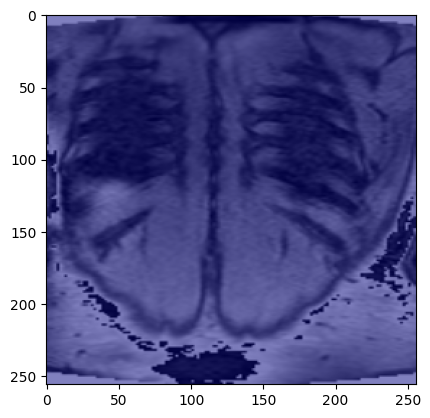

In [18]:


display_slices(image_mat, mask_mat, num = image_mat.shape[2])

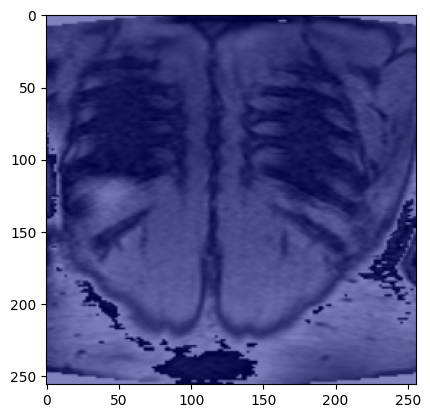

In [81]:
image_mat

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 